In [50]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import os
import copy as cp
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import zeus
import toml
from types import SimpleNamespace

import alfred.KSZ
import alfred.surveys
import alfred.utils as utils

from catwoman.shelter import Cat
from alfred.emulator import kemu
from alfred.parameters import *
from alfred.astrofit import *


In [52]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

# Introduction

This notebook contains all the code necessary to reproduce the plots of the paper

In [53]:
ells[indices]

array([ 1500,  2000,  2500,  3000,  3500,  4000,  4500,  5000,  5500,
        6000,  6500,  7500,  8500,  9500, 10500, 11500, 12500, 13500,
       14500])

In [28]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [29]:
spectra_path = 'ps_ee'

In [30]:
sims = get_sims(f'spectra/kSZ/LoReLi/nells30_v5')
print(len(sims))

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available
6797


In [31]:
df

,fX,rHS,tau,Mmin,fesc
sim_n,,,,,
12104,-1.716699,0.8,3.186730,9.33,0.275
10630,-3.540608,0.0,3.487252,8.27,0.275
14596,-1.716699,0.0,3.601125,8.53,0.050
18223,-2.884190,0.6,3.697386,8.00,0.500
12090,-2.050181,0.4,3.186730,9.33,0.275
...,...,...,...,...,...
17154,-2.217012,0.4,3.589380,8.00,0.500
11452,-2.384260,0.0,3.396862,9.07,0.275
11425,-3.211549,0.6,3.396862,9.07,0.275


In [32]:
astro_pnames_formatted

['$L_X$',
 '$f_X$',
 '$\\tau_{\\mathrm{SF}}$',
 '$M_{\\mathrm{min}}$',
 '$f_{\\mathrm{esc}}$',
 '$\\tau_{\\mathrm{CMB}}$',
 '$A_{\\mathrm{hkSZ}}$']

In [33]:
xe_histories = np.load(f'{base_dir}/metadata/ion_histories_full.npz', allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()
len(xe_histories)

9420

In [34]:
from scipy.integrate import cumulative_trapezoid

def xe2tau_plot(z):
        """
        Computes redshift evolution of the model's optical depth. This one is reversed for plotting purposes

        Parameters
        ----------
            z: (array of) float(s)
                Redshift range used to compute the optical depth.
        """
        cos = cosmology.FlatLambdaCDM(
            H0=ksz.h * 100, Tcmb0=ksz.T_cmb, Ob0=ksz.Ob_0, Om0=ksz.Om_0
        )
        z = np.sort(z)
        xe = np.sort(ksz.xe(z))[::-1]

        integ = constants.c.value * constants.sigma_T.value * ksz.nh * xe \
            / cos.H(z).si.value * (1+z)**2
        tofz = cumulative_trapezoid(integ, z, initial=0)

        return tofz

Completed 1/6797...


KeyboardInterrupt: 

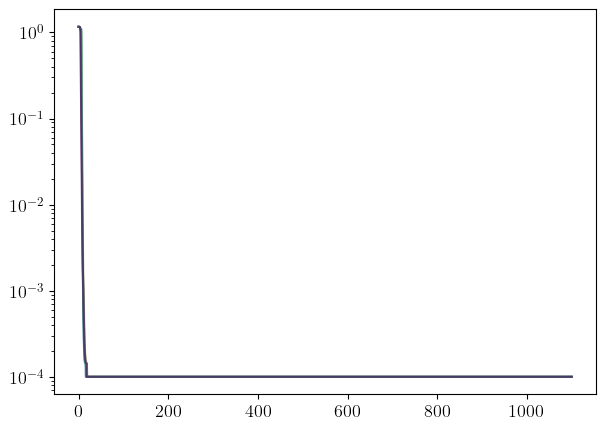

In [35]:
fig, ax = plt.subplots(sharex=True, figsize=(7,5))
fig.subplots_adjust(hspace=.00)

norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis')

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        # continue
        print(f"Completed {i+1}/{len(df)}...")


    sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        LoReLi_format=True,
                        verbose=False)
    
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                xemax=.97)
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax.semilogy(z3, ksz.xe(z3), color=color, alpha=.25)
    # ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)
    
ax.set_xlim(3.2,14.3)

ax.set_xlabel(rf"$z$", fontsize=16)
ax.set_ylabel(rf"$x_e(z)$", fontsize=16)

fig.savefig('xe.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
fig, ax = plt.subplots(2,1, sharex=True, figsize=(5,7))
fig.subplots_adjust(hspace=.00)


norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis_r')

ax[1].axhspan(Planck - Planck_err, Planck + Planck_err, color='lightpink', alpha=.1)
ax[1].axhspan(Planck - 2 * Planck_err, Planck + 2 * Planck_err, color='lightpink', alpha=.1)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f"Completed {i+1}/{len(df)}...")

    sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        LoReLi_format=True,
                        verbose=False)
    
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                xemax=.97)
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax[0].plot(z3, ksz.xe(z3), color=color, alpha=.25)
    ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)

ax[0].set_ylabel(rf"$x_e(z)$", fontsize=16)

ax[1].set_xlabel(rf"$z$", fontsize=16)
ax[1].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)

ax[1].set_xlim(0,12)
ax[1].set_ylim(0,.068)

fig.savefig('xe_and_tau.png')

In [39]:
# priors = [(df[p].to_numpy().min(), df[p].to_numpy().max()) for p in df.columns]

norms = []
for p in priors:
    vmin = p[0]
    vmax = p[1]

    n = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    norms.append(n)

cmap = plt.get_cmap('viridis')

In [ ]:
fig, ax = plt.subplots(1,6, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0)

import alfred.utils as utils

mob = []
tspecs_mob  = np.zeros((len(validation_sims), len(ells[indices])))
especs_mob = np.zeros_like(tspecs_mob)

for i in range(5):
    print(f"Now on {i} run...")
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

    tspecs  = np.zeros((len(validation_sims), len(ells[indices])))
    especs = np.zeros_like(tspecs)

    for si, sn in enumerate(validation_sims):
        # if si % 100 != 0:
        #     continue
        tspec = utils.spectra(sn)[indices]
        espec = emulator.kemu(df.loc[sn].to_numpy(), **emu)
        residual =  espec - tspec

        tspecs[si] = tspec
        especs[si] = espec

        if sn in bad:
            color = 'tomato'
        elif sn in good:
            color = 'navy'

        l = ax[i].plot(ells[indices], residual, color=color, alpha=.1)

        mob.append(emu)

print(f"On validation mob")
for si, sn in enumerate(validation_sims):
    if si % 1000 == 0:
        print(f"On i={si} sim...")
    #     continue
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)
    residual =  espec - tspec

    tspecs_mob[si] = tspec
    especs_mob[si] = espec

    if sn in bad:
        color = 'tomato'
    elif sn in good:
        color = 'navy'

    # print(residual)

    l = ax[-1].plot(ells[indices], residual, color=color, alpha=.1)
    
    # if lowbias[i]:
    #     color = 'navy'
    # elif not lowbias[i]:
    #     color = 'tomato'
    # l =ax[0].plot(ells[indices], tspec, color='navy', alpha=.1)
    # l =ax[0].plot(ells[indices], espec, color='tomato', alpha=.1)
ax[0].set_ylim(-.1,.1)
    

On 0th sim
On 1000th sim
On 2000th sim
13925
0.87817
On 3000th sim
On 4000th sim
On 5000th sim
On 6000th sim


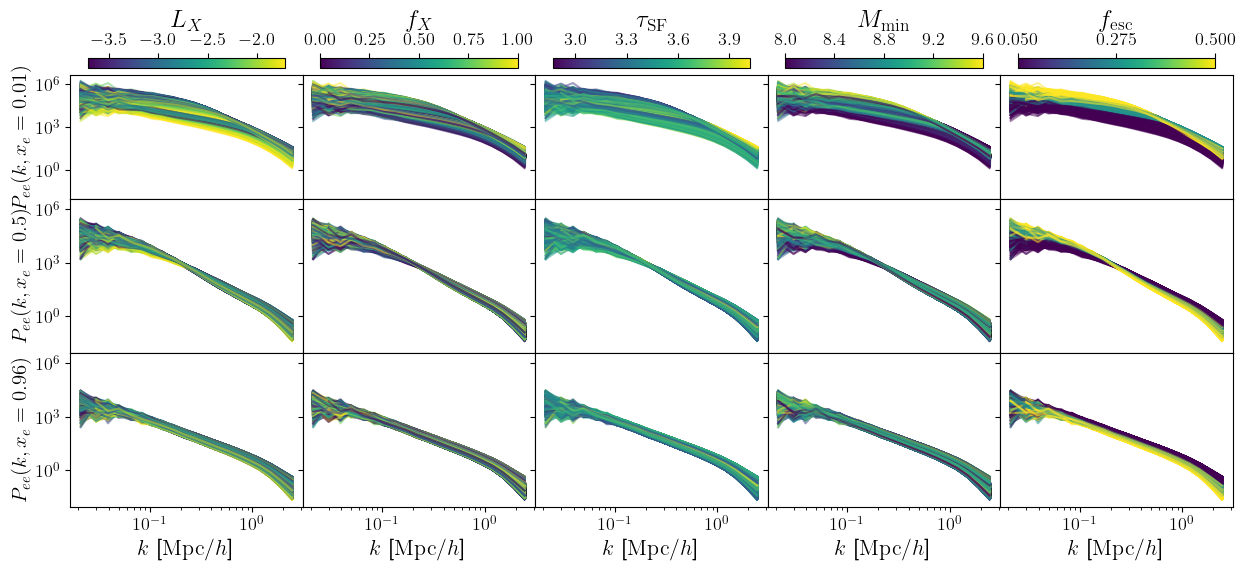

In [38]:
from scipy.interpolate import interp1d

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 5, figsize=(15,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
        # continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn]):
            color = cmap(norms[pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

ax = axes[0]
for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"$P_{{ee}}(k, x_{{e}}={xei})$", fontsize=15)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}$/$h$]', fontsize=16) for a in axes[-1]]

fig.savefig('LoReLi_suite.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

$L_X$
$f_X$
$\tau_{\mathrm{SF}}$
$M_{\mathrm{min}}$
$f_{\mathrm{esc}}$


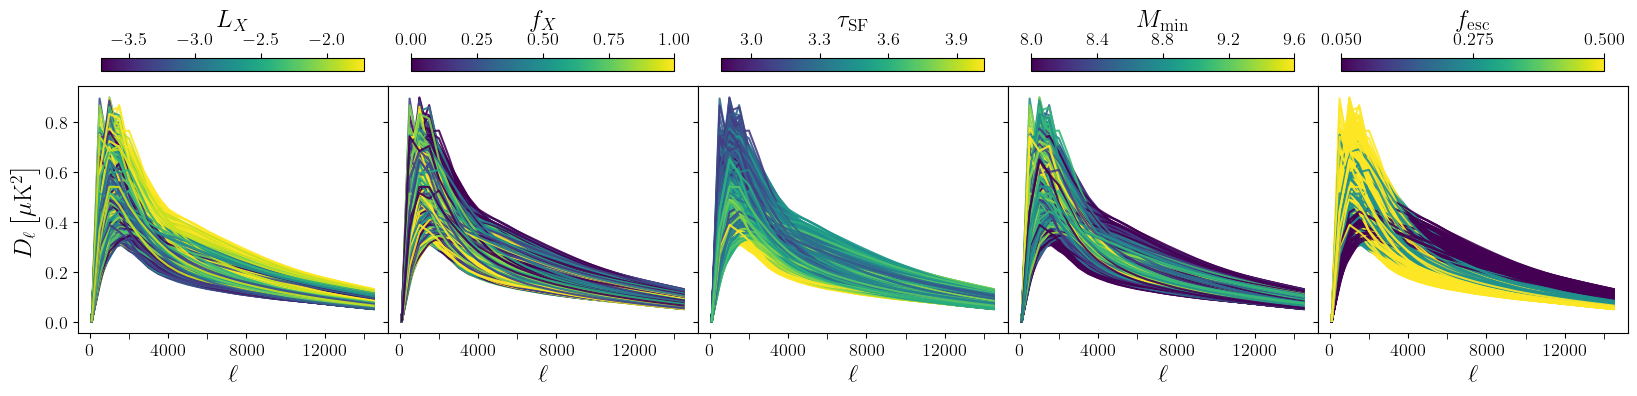

In [42]:
fig, ax = plt.subplots(1,5, sharex=True, sharey=True, figsize=(20,4))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.9)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[i])
    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=18)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=10)

ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=18)

for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

# Add minor ticks to x-axis


fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

### Fiducial simulation

In [ ]:
fig, ax = plt.subplots(2,5, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

emu_paths = ['setrandomseed3/emuv5.1', 'reduced_dataset2/emuv5.0']
xfesc = np.linspace(*priors[4], 12)

N = len(xfesc)
cmap = matplotlib.cm.get_cmap('viridis')

# Generate N evenly spaced values in [0, 1]
colors = [cmap(i / (N - 1)) for i in range(N)]
for i, path in enumerate(emu_paths):
    for n in range(5):
        emu = summon_emu(f"{path}_run{n}", verbose=True)
        tspec = emulator.kemu(true_params, **emu)
        for it, t in enumerate(xfesc):
            params = cp.deepcopy(true_params)
            params[4] = t
            espec = emulator.kemu(params, **emu)

            label = ''
            if (i == 0) and (n==0):
                label = f"fesc={t:.3f}"
            ax[i,n].plot(ells[indices], tspec - espec, color=colors[it], label=label)

            ax[1,n].set_xlabel('ells')
            ax[0,0].set_ylabel('v5.1 style')
            ax[1,0].set_ylabel('v5.0 style')

fig.legend()


In [139]:
params = df.loc[config.sn].to_numpy()
truths = dict(zip(df.columns, params))

print(f"fitting simu{config.sn} with params:")
print(params)

fiducial = alfred.utils.spectra(config.sn)

fitting simu12958 with params:
[-1.71669877  0.          3.27712767  8.53        0.275     ]


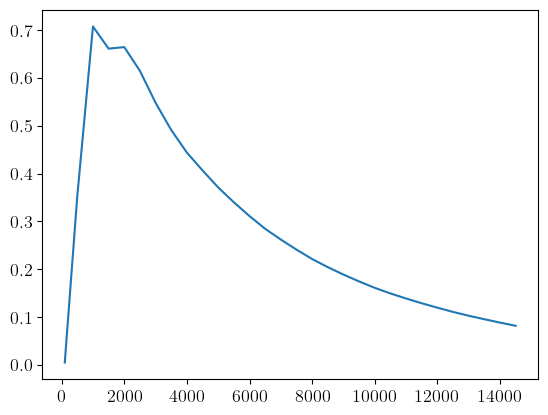

In [135]:
plt.plot(ells, fiducial)

### Surveys

We also need to assume some experimental noise configurations in order to generate our mock data. Here we plot the noise levels for each assumed survey setup.

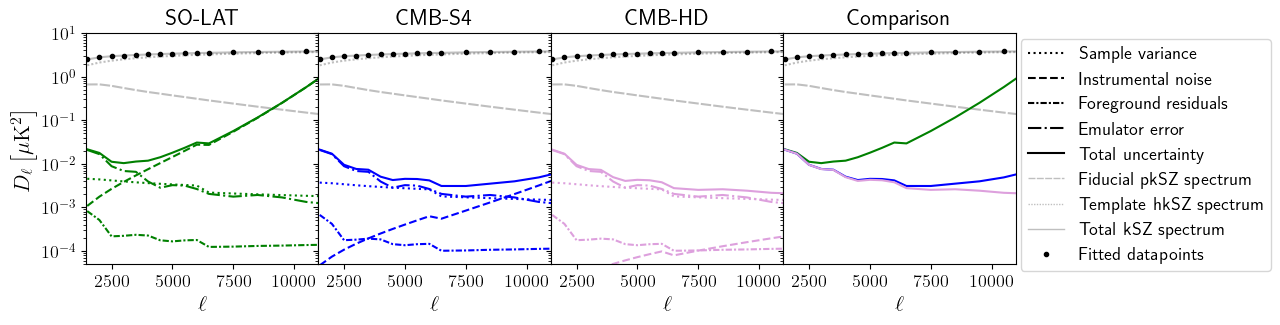

In [50]:
fig, ax = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,3))
fig.subplots_adjust(wspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator

from matplotlib.lines import Line2D

from alfred.parameters import colors

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle=(0, (3, 1, 1, 1)), alpha=1.0, label='Foreground residuals'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle=(0, (5, 1)), alpha=.25, linewidth=1.0, label=f'Fiducial pkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle=(0, (1, 1)), alpha=.25, linewidth=1.0, label=f'Template hkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.25, linewidth=1.0, label=f'Total kSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

data = np.load(f"{base_dir}/inference/productionruns6_addhksz/CMB-HD/noiseless/data.npz")
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells[indices], hksz[0], hksz[1])

fiducial = utils.spectra(config.sn)[indices] + 2.5 * hksz

ax[3].plot(ells[indices], fiducial, color='black', alpha=.25)
ax[3].plot(ells[indices], fiducial, color='black', marker='.', ls='')

ax[3].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.25, ls=(0, (5, 1)))
ax[3].plot(ells[indices], 2.5 * hksz, color='black', alpha=.25, ls=(0, (1, 1)))

for i, tele in enumerate(['SO-LAT', 'CMB-S4', 'CMB-HD']):

    ax[i].plot(ells[indices], fiducial, color='black', alpha=.25)
    ax[i].plot(ells[indices], fiducial, color='black', marker='.', ls='')

    ax[i].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.25, ls=(0, (5, 1)))
    ax[i].plot(ells[indices], 2.5 * hksz, color='black', alpha=.25, ls=(0, (1, 1)))

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, color=colors[i], ls=':')

    # Instrumental noise
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=True, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='noise' if i == 2 else None,
                color=colors[i], ls='--')

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=False, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls='dashdot')

    # Foreground residuals
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=False, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls=(0, (3, 1, 1, 1)))

    # Total uncertainty
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i])
    
    ax[i].set_title(f'{tele}', fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

    ax[3].plot(ells[indices], err, color=colors[i])

ax[2].plot([],[])

ax[3].set_title(f'Comparison', fontsize=16)
ax[3].set_xlabel(rf"$\ell$", fontsize=16)

ax[0].set_xlim(1450, 11000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=16)
ax[0].set_ylim(5e-5,10)
#ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].xaxis.set_major_locator(MultipleLocator(2500))
#ax[0].xaxis.set_minor_locator(MultipleLocator(500))
fig.legend(handles=legend_lines, loc='upper right', fontsize=13, bbox_to_anchor=(1.12, .89))

fig.savefig('surveys_comp.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


### Ionisation Histories and the Optical Depth, $\tau$

In [288]:
xe_histories = np.load(f"{base_dir}/metadata/xe_histories_from_spectra.npz", allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

In [ ]:
fig.savefig('xion_tau.png')

In [ ]:
diff, Planck_sn

(np.float64(0.014014080573021143), '15060')

In [ ]:
sim = Cat(Planck_sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        path_redshifts=redshift_file,
                        LoReLi_format=True,
                        verbose=False)
    
ksz = KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                    helium_interp=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                    xemax=.97)
        

fn = f'{home_dir}/nells30_v2/kSZ_LoReLi_simu{Planck_sn}.npz'
LoReLi = np.load(fn)

print(f"tau:{ksz.tau:.3f}")
print(f"tau:{ksz.tau + diff:.3f}")

tau:0.040
tau:0.054


### Fiducial simulation

In [55]:
true_params = np.asarray([*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())])
true_params

array([-1.71669877,  0.        ,  3.27712767,  8.53      ,  0.275     ,
        0.05526446])

## Emulator performance and stability

Loading in our chosen emulator

In [37]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)

nruns = 5
mob = []
for n in range(nruns):
    emu = summon_emu(f"{config.nndir}/emuv5.1_run{n}")
    mob.append(emu)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


plotting 39 sims...


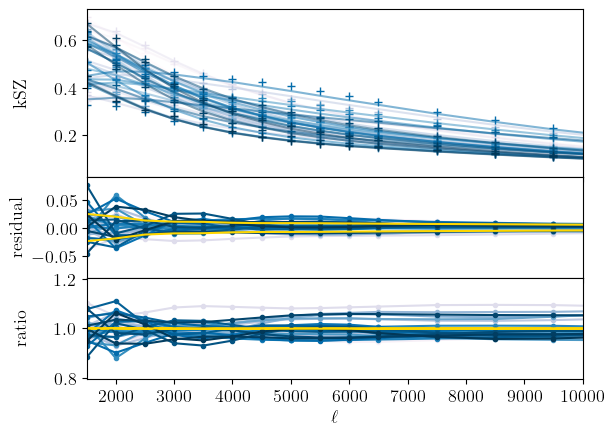

In [47]:
fig, ax = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios': [5, 3, 3]})
fig.subplots_adjust(wspace=0.0, hspace=0.0)

skipping = 35
sims_to_plot = validation_sims[::skipping]
print(f"plotting {len(sims_to_plot)} sims...")

N = len(sims_to_plot)
cmap = matplotlib.colormaps['PuBu']
    
# Generate N evenly spaced values in [0, 1]
ksz_colors = [cmap(i / (N - 1)) for i in range(N)]

data_ref = np.load(f"{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz")
std = np.load(f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy")

for i, sn in enumerate(sims_to_plot):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.kemu(df.loc[sn].to_numpy(), mob)

    ax[0].plot(ells[indices], tspec, marker='+', ls='', color=ksz_colors[i])
    ax[0].plot(ells[indices], espec, alpha=.5, color=ksz_colors[i])

    ax[1].plot(ells[indices], tspec - espec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], espec / tspec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], data_ref['Ashape'], color='gold')

ax[1].plot(ells[indices], -std, color='gold')
ax[1].plot(ells[indices], std, color='gold')

# a1.plot(x, y)
# a2.plot(x, y)

ax[0].set_xlim(1500,10000)
ax[1].set_ylim(-.09, .09)
ax[2].set_ylim(.795, 1.205)

ax[2].set_xlabel(rf"$\ell$")

ax[0].set_ylabel(rf"$\mathrm{{kSZ}}$")
ax[1].set_ylabel(rf"$\mathrm{{residual}}$")
ax[2].set_ylabel(rf"$\mathrm{{ratio}}$")

ax[0].yaxis.set_label_coords(-0.115, 0.5) 
ax[2].yaxis.set_label_coords(-0.115, 0.5) 

fig.savefig("NNemulator.png", bbox_inches='tight', pad_inches=0.05, dpi=300)

In [58]:
def degeneracy(Mmin, slope=priors2d['m'], intercept=priors2d['b_below']):
    return priors2d['m'] * Mmin + priors2d['b_below']

xMmin = np.linspace(*priors[3],10)
xtau = degeneracy(xMmin)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('viridis')
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` o

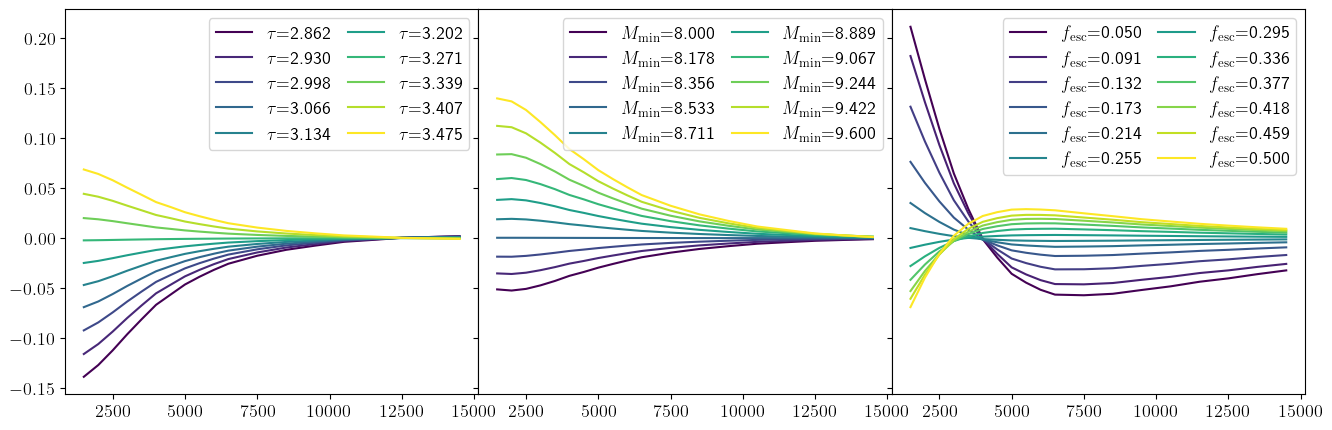

In [79]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(16,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

params_x = [xtau[::-1], xMmin, xfesc]

for i_param, prange in enumerate(params_x):
    N = len(prange)
    cmap = matplotlib.cm.get_cmap('viridis')
    
    # Generate N evenly spaced values in [0, 1]
    colors = [cmap(i / (N - 1)) for i in range(N)]
    for it, t in enumerate(prange):
        params = cp.deepcopy(true_params[:-1])
        params[2+i_param] = t
        espec = emulator.mechkemu(params, mob)
        label = rf"{astro_pnames_formatted[2+i_param]}$=${t:.3f}"
        ax[i_param].plot(ells[indices], tspec - espec, color=colors[it], label=label)
        ax[i_param].legend(ncol=2, columnspacing=1.0, fontsize=13)

fig.savefig('x_vs_dkSZ.png', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [44]:
samples

array([[-2.79721189,  0.19627005,  3.66770594,  8.04797253,  0.42621474],
       [-2.32323812,  0.17636773,  3.31828961,  9.55882617,  0.13174127],
       [-3.66792151,  0.11632865,  3.27298402,  8.83525598,  0.1073423 ],
       ...,
       [-2.84047047,  0.03494826,  3.18765722,  9.52513095,  0.06699478],
       [-2.53079057,  0.13263233,  3.92487386,  8.11045816,  0.27302342],
       [-3.03547066,  0.5471112 ,  3.46611226,  8.64786835,  0.34987466]],
      shape=(1000, 5))

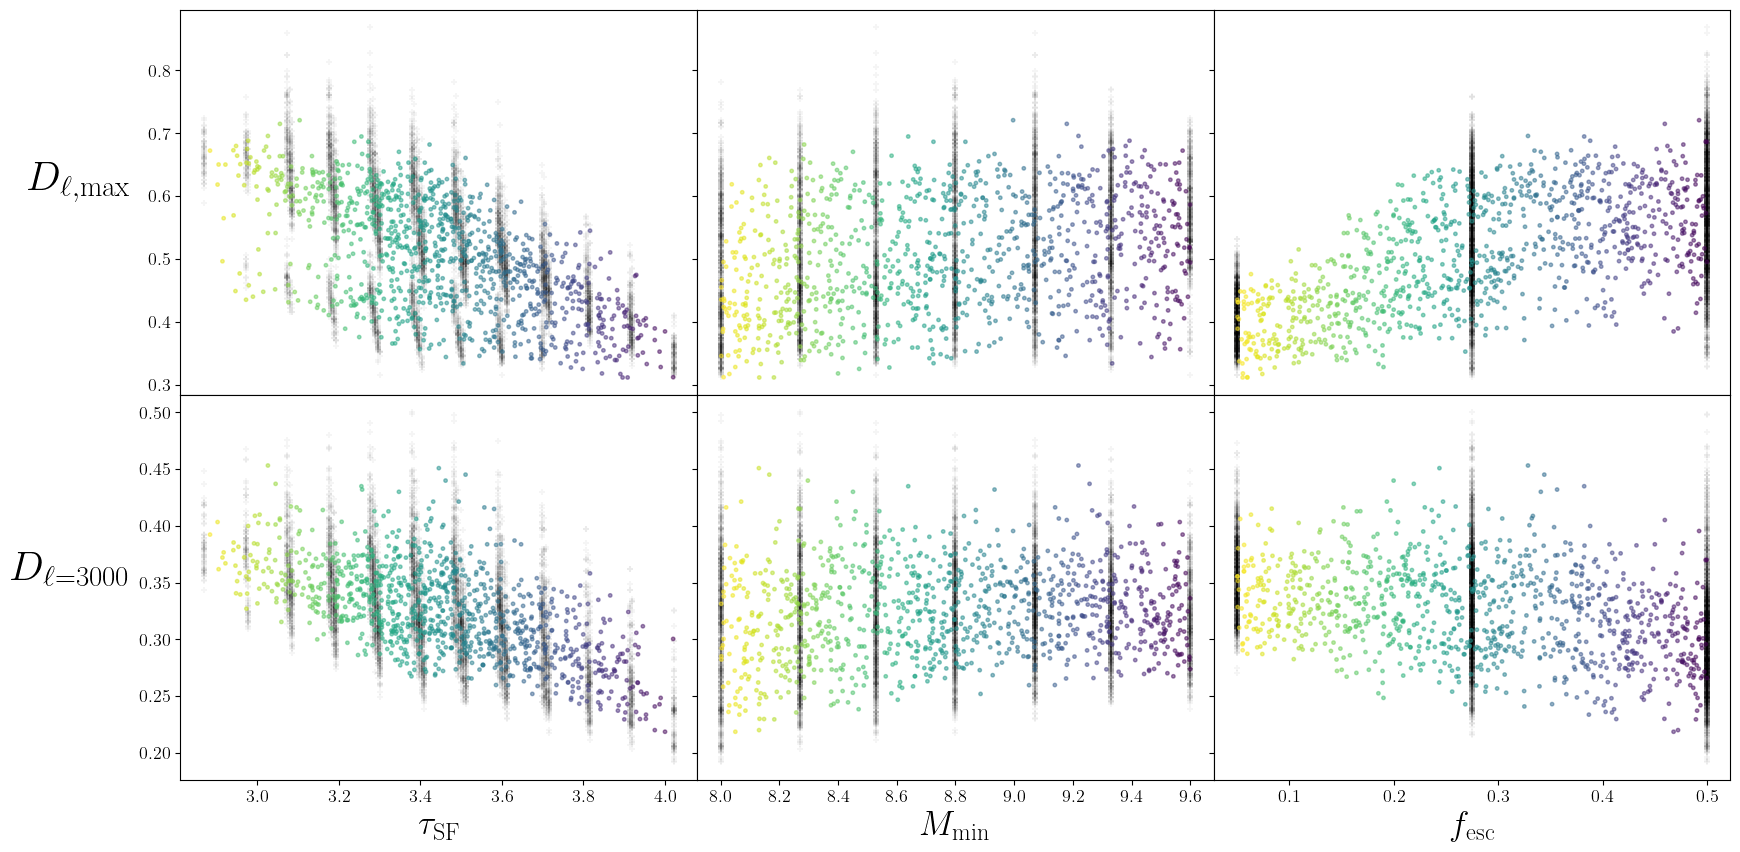

In [45]:
fig, ax = plt.subplots(2,len(df.columns.to_list()[2:]), sharex='col', sharey='row', figsize=(20,10))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

samples = draws(1000)

params = df.to_numpy()
data = np.zeros((len(df), len(ells[indices])))
for i_sim, sn in enumerate(df.index):
    data[i_sim] = utils.spectra(sn)[indices]
    
signal = emulator.kemu(samples, mob)
color = cmap(norm(params[-1]))

skwargs = {'marker':'.', 
           's':25,
           'alpha':.5,
           'color':color,
           'rasterized': True}

for i, pname in enumerate(df.columns.to_list()[2:]):
    skwargs['marker'] = '+'
    skwargs['alpha'] = .04
    skwargs['color'] = 'black'

    ax[0,i].scatter(params[:,2+i], np.max(data, axis=1), **skwargs)
    # ax[1,i].scatter(params[:,i], ells[indices][np.argmax(data[:,1:], axis=1)], **skwargs)
    ax[1,i].scatter(params[:,2+i], data[:,4], **skwargs)

    skwargs['color'] = cmap(norms[2+i](samples[:,2+i]))
    skwargs['marker'] = '.'
    skwargs['alpha'] = .5

    ax[0,i].scatter(samples[:,2+i], np.max(signal, axis=1), **skwargs)
    # ax[1,i].scatter(samples[:,i], ells[indices][np.argmax(signal, axis=1)], **skwargs)
    ax[1,i].scatter(samples[:,2+i],  signal[:,4], **skwargs)

    ax[1,i].set_xlabel(astro_pnames_formatted[2+i], fontsize=25)

ax[0, 0].set_ylabel(r"$D_{\ell, \mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
# ax[1, 0].set_ylabel(r"$\ell_{\mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[1, 0].set_ylabel(r"$D_{\ell=3000}$", fontsize=30, rotation=0, labelpad=50)

# ax[1,0].set_ylim(1000, 3000)

fig.savefig('trends2.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)



# Section 4     Results

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/SO-LAT/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-S4/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-HD/noiseless...


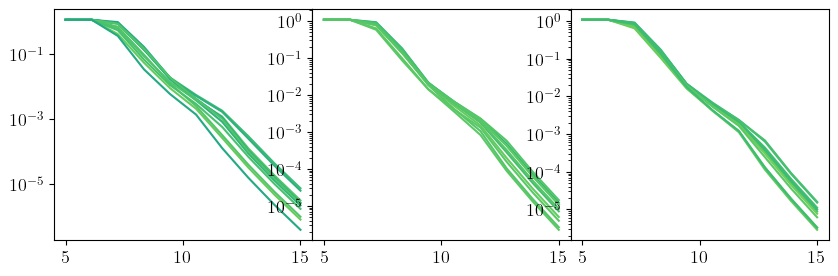

In [69]:
mcmcdir = f"{base_dir}/inference/productionruns6_addhksz"
survey_list = ['SO-LAT', 'CMB-S4', 'CMB-HD']
data = np.load(f"{base_dir}/inference/productionruns6_mechaemu/{survey_list[0]}/noiseless/data.npz")

fig, ax = plt.subplots(1,3, figsize=(10,3))
fig.subplots_adjust( wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

chains = []
ztau = np.linspace(5,15,10)
for i, s in enumerate(survey_list):
    s, l = utils.load_samples(f"{mcmcdir}/{s}/noiseless")
    chains.append(s)
    params = fill(s, df.loc[config.sn].to_dict(), df.columns[2:])
    xe = keras_xe_emul.xe_emul_array(ztau, params, plot=False)

    for n in range(1,10000,1000):
        ax[i].semilogy(ztau, xe[n].T, color=cmap(norm(params[n,-1])))


(120000, 5)

1.0475159887931482


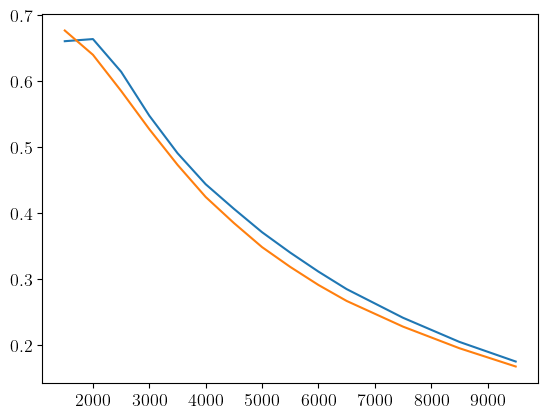

In [14]:
plt.plot(data['ells'], data['datapoints'])
plt.plot(data['ells'], data['model'])

print(np.mean(data['datapoints'] / data['model']))

In [19]:
2.5 / (data['datapoints'].max() + 2.5), data['datapoints'].max()

(np.float64(0.7901070634234324), np.float64(0.6641281488711432))

In [47]:
survey_list

['SO-LAT', 'CMB-S4', 'CMB-HD']

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


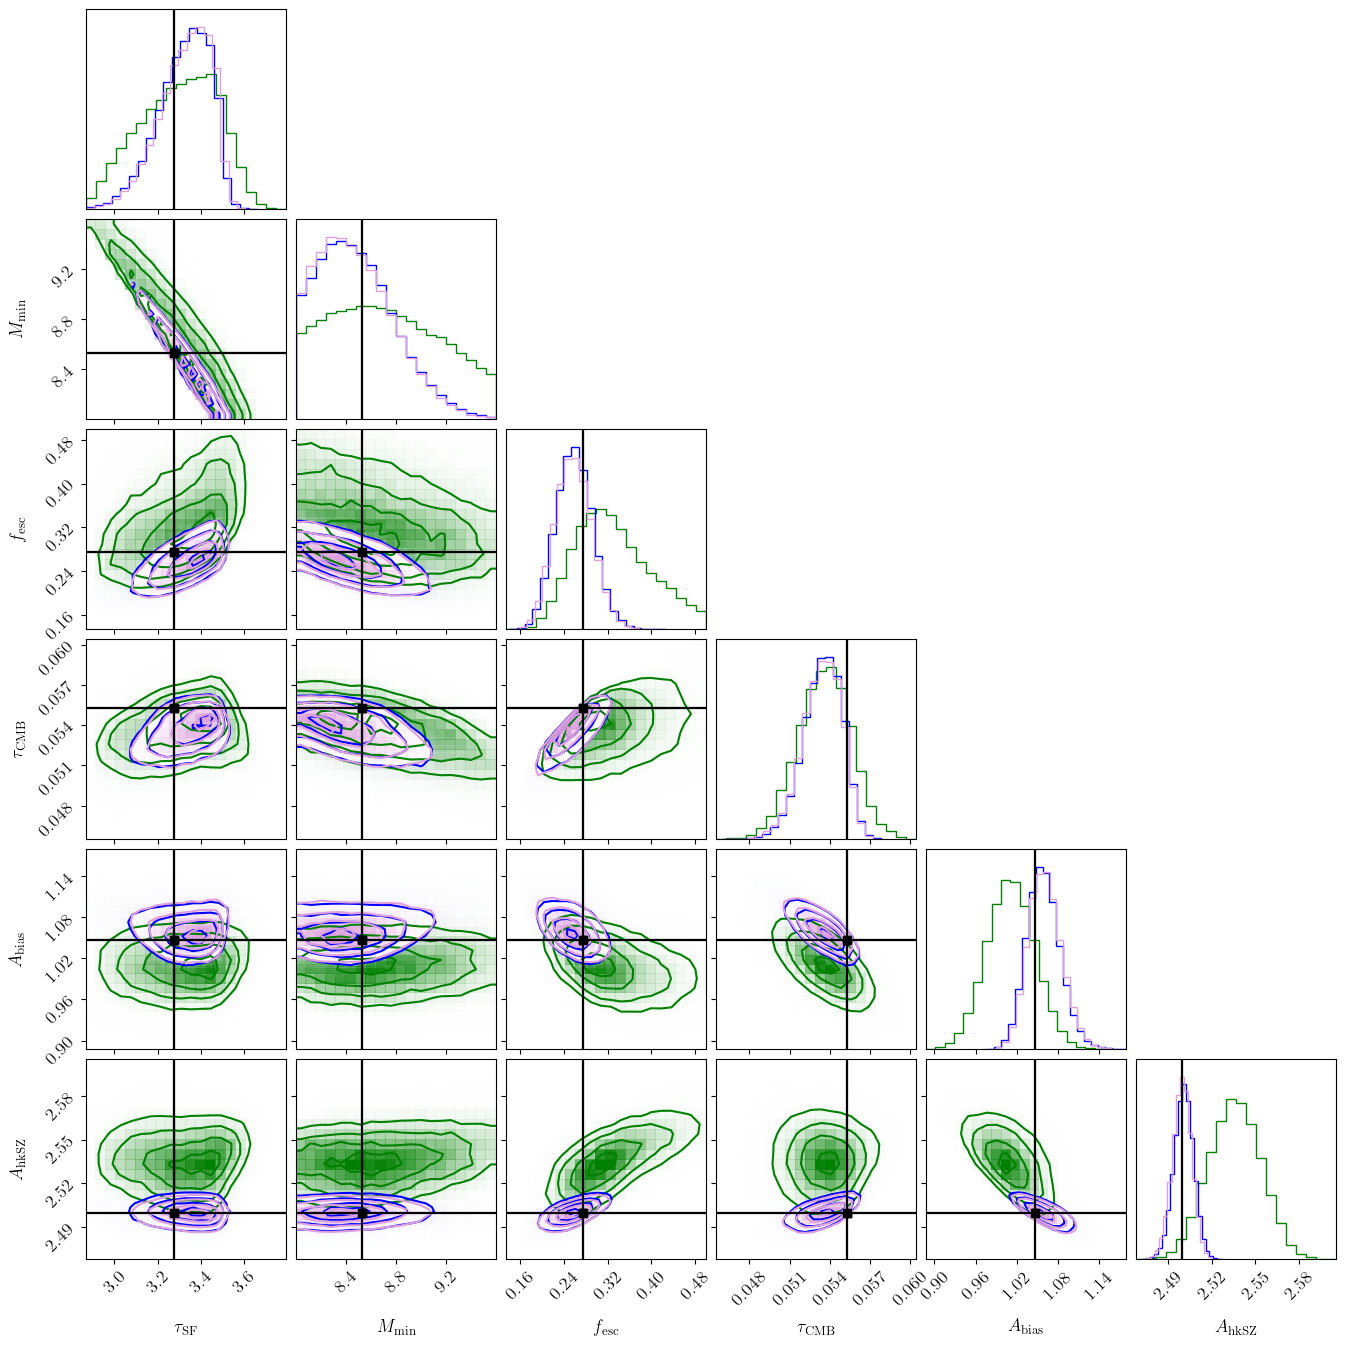

In [70]:
# pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']
pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$\\tau_{\\mathrm{CMB}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$']

true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
true_values = dict(zip(pnames, [*true_params[2:], np.mean(data['datapoints'] / data['model']), 2.5]))



cornerfig = None

for i, chain in enumerate(chains):
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    np.save(f'samples_wtau_{survey_list[i]}', chaintau)
    fig = corner.corner(chaintau, fig=cornerfig, color=colors[i],
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    cornerfig = fig


cornerfig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
for i, chain in enumerate(chains):

## Appendix Plots

In [52]:
import os
import re

directory = f"{base_dir}/cuts"
pattern = re.compile(r".*\d{5}.*\.npz$")  # matches exact 5-digit numbers

fns = []
for filename in os.listdir(directory):
    if pattern.search(filename):
        fns.append(filename)

fns

['simu10539_cuts.npz',
 'simu10059_cuts.npz',
 'simu11933_cuts.npz',
 'simu14107_cuts.npz',
 'simu13646_cuts.npz',
 'simu15060_cuts.npz',
 'simu10528_cuts.npz',
 'simu12286_cuts.npz',
 'simu10835_cuts.npz',
 'simu10245_cuts.npz',
 'simu15042_cuts.npz',
 'simu12327_cuts.npz',
 'simu17099_cuts.npz',
 'simu10505_cuts.npz',
 'simu13873_cuts.npz',
 'simu11501_cuts.npz',
 'simu10324_cuts.npz',
 'simu12792_cuts.npz',
 'simu11174_cuts.npz',
 'simu12039_cuts.npz']

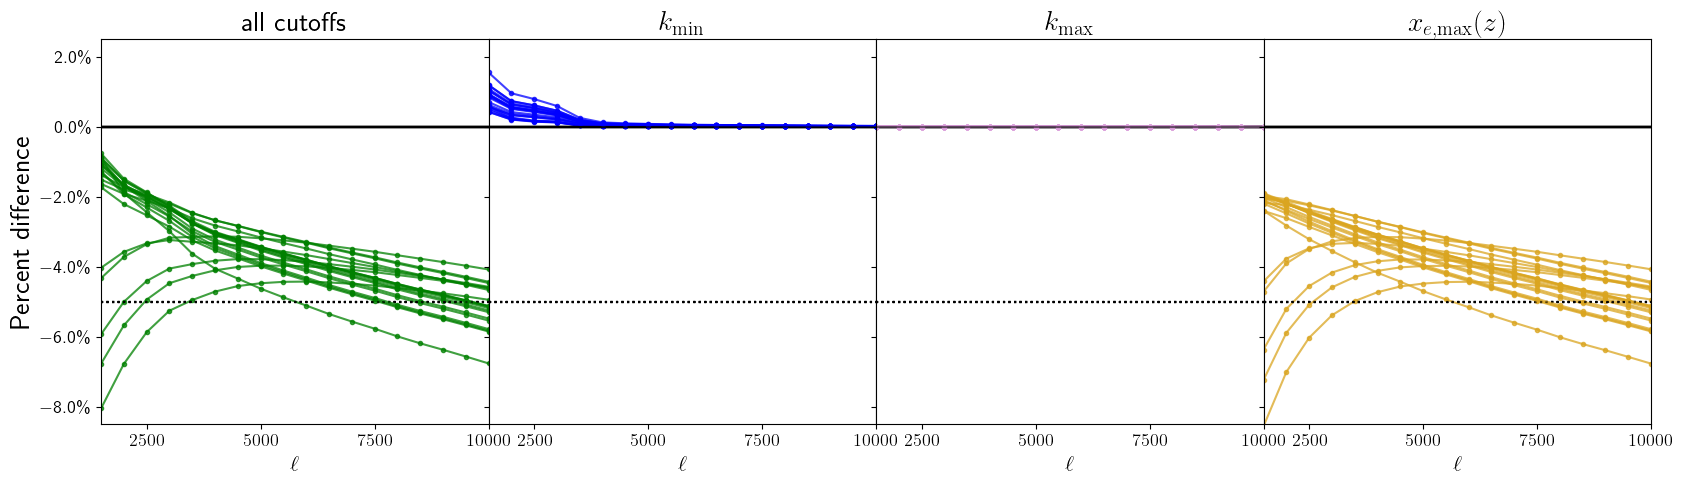

In [86]:
from matplotlib.ticker import PercentFormatter

cuts = ['uncut',  'cut', 'kmin', 'kmax', 'xemax']
labels = ['all cutoffs', r'$k_{\mathrm{min}}$', r'$k_{\mathrm{max}}$', r'$x_{e,\mathrm{max}} (z)$']

fig, axes = plt.subplots(1,len(cuts[1:]), sharex=True, sharey=True, figsize=(20,5))
fig.subplots_adjust(wspace=0.0)

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)


    for i, ax in enumerate(axes):

        ax.plot(ells, (kSZ[cuts[i+1]] - kSZ['uncut']) / kSZ['uncut'], color=colors[i], alpha=.75, marker='.', label=fn)

        ax.axhline(0.0, color='black', alpha=.5)

        ax.axhline(-.1, color='black', alpha=.1, ls=":")
        ax.axhline(.1, color='black', alpha=.1, ls=":")

        ax.axhline(-.05, color='black', alpha=.25, ls=":")
        ax.axhline(.05, color='black', alpha=.25, ls=":")

        ax.axvline(1000, color='green')
        ax.axvline(1000, color='green')

        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_title(f"{labels[i]}", fontsize=20)
#plt.legend()
        ax.set_xlim(1500, 10000)
        ax.set_ylim(-.085,.025)
        ax.xaxis.set_major_locator(MultipleLocator(2500))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
axes[0].set_ylabel('Percent difference', fontsize=20)

fig.savefig('cuts.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
k_res[1]

2.7170531058073886

0.021226977389120223
cutoff at 0.022272727272727274 vs 1e-06
1.5
cutoff at 1.526315789473684 vs 10000.0
0.00416667
cutoff at 0.004166666666666667 vs 0.0


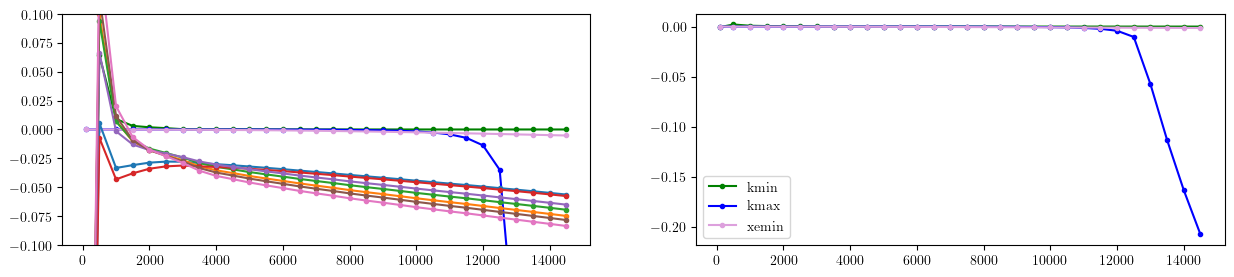

In [ ]:
cuts = [kmin_cuts, kmax_cuts, xemin_cuts, xemax_cuts]
vals = [k_res[0], 1.5, 0.00416667, .97]
lab = ['kmin', 'kmax', 'xemin', 'xemax']

fig, ax = plt.subplots(1,2, figsize=(15,3))

for i, c in enumerate(cuts[:-1]):
    Dells = c['Dells']
    cuts = c['cuts']

    print(vals[i])

    if i % 2 == 0:
        j = 0
    elif i % 2 == 1:
        j = -1

    index = np.argmin(np.abs(cuts - vals[i]))
    print(f"cutoff at {cuts[index]} vs {cuts[j]}")

    ax[0].plot(ells, ((Dells[index] - Dells[j]) / Dells[j]), label=lab[i], marker='.', color=colors[i])
    ax[1].plot(ells, (Dells[index] - Dells[j]), label=lab[i], marker='.', color=colors[i])

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)

    ax[0].plot(ells, (kSZ['cut'] - kSZ['uncut']) / kSZ['uncut'], marker='.')

#plt.xlim(500, 8000)
ax[0].set_ylim(-.1,.1)
plt.legend()

In [ ]:
k_res[0]

0.021226977389120223

In [ ]:
np.arange(ksz.find_zpiv(), 10.0, step=dz)

array([4.40909884, 4.55909884, 4.70909884, 4.85909884, 5.00909884,
       5.15909884, 5.30909884, 5.45909884, 5.60909884, 5.75909884,
       5.90909884, 6.05909884, 6.20909884, 6.35909884, 6.50909884,
       6.65909884, 6.80909884, 6.95909884, 7.10909884, 7.25909884,
       7.40909884, 7.55909884, 7.70909884, 7.85909884, 8.00909884,
       8.15909884, 8.30909884, 8.45909884, 8.60909884, 8.75909884,
       8.90909884, 9.05909884, 9.20909884, 9.35909884, 9.50909884,
       9.65909884, 9.80909884, 9.95909884])

In [ ]:
zpiv = ksz.find_zpiv()
z_pre =  np.logspace(np.log10(z_min), np.log10(zpiv),
    int((np.log10(zpiv) - np.log10(z_min)) / dlogz) + 1)

z_EOR = np.arange(zpiv + dz, 10.0, step=dz)
z_post = np.arange(10, z_max + 0.5, step=0.5)

z_integ = np.concatenate((z_pre, z_EOR, z_post))


In [ ]:
ksz.xe(ksz.find_zpiv()), ksz.xe_spline(ksz.find_zpiv()), ksz.find_zpiv()

here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0


(array(1.0510521), array(0.97), 4.409098837209303)

here
True
here2
1.0817405673349607


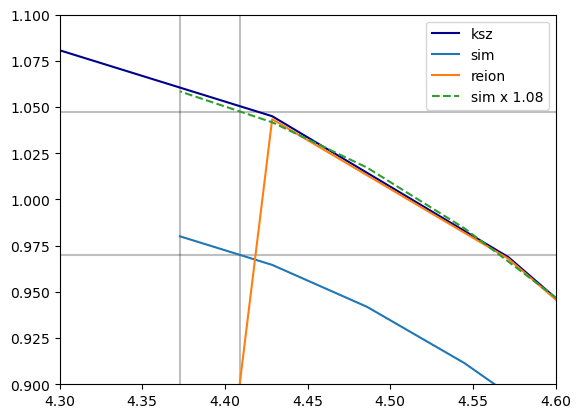

In [ ]:
plt.axvline(4.409098837209303, color='black', alpha=.25)
plt.axvline(sim.z.min(), color='black', alpha=.25)

plt.axhline(.97, color='black', alpha=.25)
plt.axhline(1.08 * .97, color='black', alpha=.25)

xe = ksz.xe(z)

plt.plot(z, xe, color='darkblue', label='ksz')
plt.plot(sim.z, sim.xe, label='sim')
plt.plot(z, ksz.xe_reion, label='reion')


plt.plot(sim.z, 1.08 * sim.xe, ls='--', label='sim x 1.08')




plt.xlim(4.3, 4.6)
plt.ylim(.9,1.1)
plt.legend()

In [ ]:
print('Redshifts are:')
print(z)
print()

print(f"Early ends at {ksz.z_data.max()}")
print(ksz.xe_early)
print()

print(f"Reion from {ksz.z_data.min()} to {ksz.z_data.max()}")
print(ksz.xe_reion)
print()

print(f"Late")
print(ksz.xe_late)
print()

print(ksz.xe_He)
print()

Redshifts are:
[ 3.          3.14285714  3.28571429  3.42857143  3.57142857  3.71428571
  3.85714286  4.          4.14285714  4.28571429  4.42857143  4.57142857
  4.71428571  4.85714286  5.          5.14285714  5.28571429  5.42857143
  5.57142857  5.71428571  5.85714286  6.          6.14285714  6.28571429
  6.42857143  6.57142857  6.71428571  6.85714286  7.          7.14285714
  7.28571429  7.42857143  7.57142857  7.71428571  7.85714286  8.
  8.14285714  8.28571429  8.42857143  8.57142857  8.71428571  8.85714286
  9.          9.14285714  9.28571429  9.42857143  9.57142857  9.71428571
  9.85714286 10.        ]

Early ends at 18.795
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

Reion from 4.3728 to 18.795
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         1.04344471 0.96794
 0.85784361 0.73712865 0.62617375 0.53079526 0.45014085

In [ ]:
ksz.find_zpiv()

here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0


4.409098837209303

In [ ]:
zpiv = ksz.find_zpiv()

1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.96459
late 0.0
He 0
1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.9673654384515687
late 0.0
He 0
1.0
early 0.0
reion 0.9697873139940252
late 0.0
He 0
1.0
early 0.0
reion 0.9699902002012757
late 0.0
He 0
1.0
early 0.0
reion 0.9699999603593609
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999925594
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999999999
late 0.0
He 0
1.0
early 0.0
reion 0.9700000000002778
late 0.0
He 0


In [ ]:
zpiv

4.409098837209303

In [ ]:
ksz.xe_spline(zpiv), ksz.xe(zpiv)

1.0817405673349607
early 0.0
reion 1.0492883503149117
late 0.0
He 0.0017637483296882278


(array(0.97), array(1.0510521))

In [ ]:
ksz.xe_early + ksz.xe_reion + ksz.xe_late + ksz.xe_He

np.float64(1.0510520986446)

In [ ]:
ksz.xe_early, ksz.xe_reion, ksz.xe_late, ksz.xe_He

(array(0.),
 np.float64(1.0492883503149117),
 array(0.),
 np.float64(0.0017637483296882278))

In [ ]:
.97 * 1.08 + ksz.xe_He

np.float64(1.0493637483296883)

In [ ]:
ksz.xe(30)

1.0817405673349607
early 0.0001
reion 0.0
late 0.0
He 0.0


array(0.0001)

In [ ]:
z = np.linspace(3,10)



here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607


array(1.0510521)